In [4]:
import jax.numpy as jnp
import numpy as np

import equinox as eqx

from models import *

In [5]:
from exp import exp as ex

In [6]:
model = ex.model
EX = ex.EX
steps = 64000

eta = ex.eta
y0 = ex.y0
ts = ex.ts
ys = ex.ys

ts_eval = ex.ts_eval

exp_name = ex.exp_name
path = f"results/{exp_name}"
param_path = f"{path}/model_parameter/model_step_{steps:05d}.eqx"
# loss_list = np.load(f"{path}/loss_list.npy")

EX.model = eqx.tree_deserialise_leaves(
    param_path,
    EX.model
)

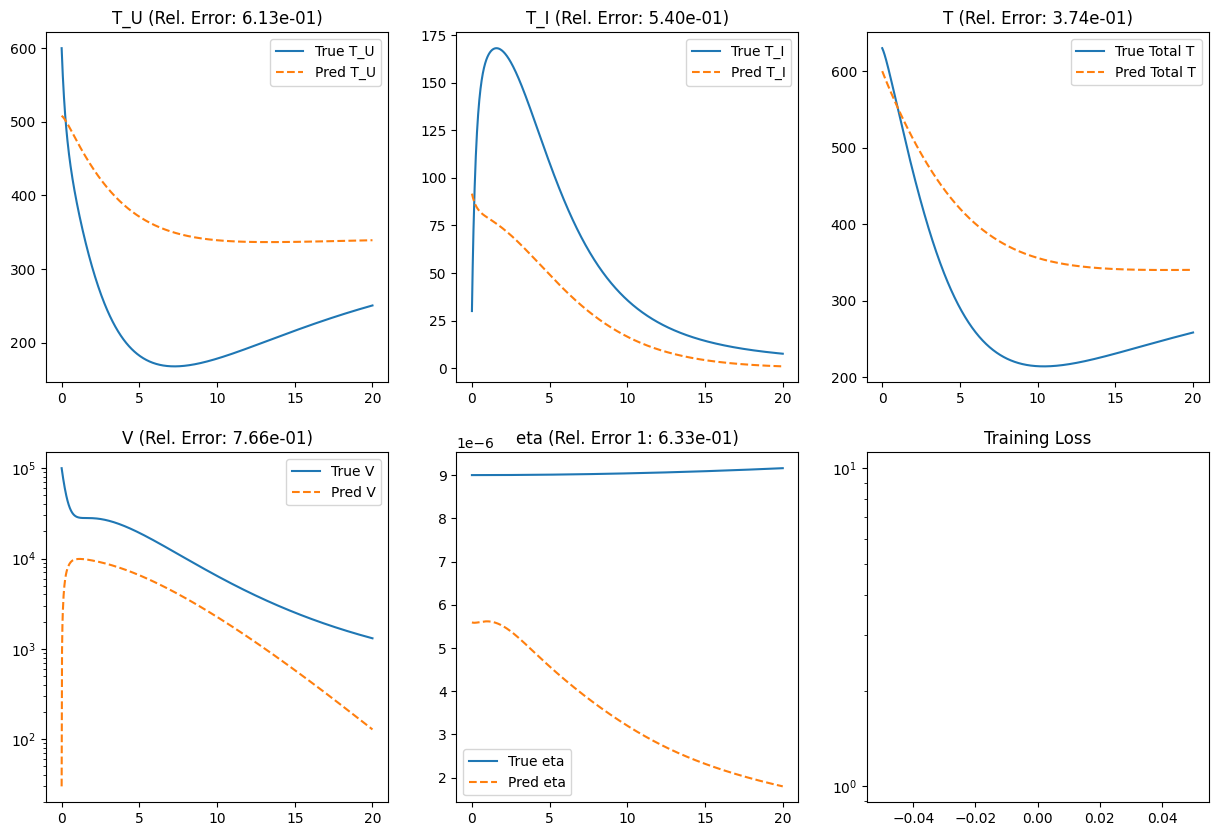

In [7]:
model.Evaluation(EX, y0, ts_eval, [], viz_data=False)

In [8]:
ll, rr, N, dd, c = jnp.abs(EX.model.parameter)
print(f"parameter - lambda:{ll:.4f}, rho:{rr:.4f}, N:{N:.4f}, delta:{dd:.4f}, c:{c:.4f}")

parameter - lambda:34.1518, rho:2.2621, N:1048.9700, delta:0.7093, c:3.2842


In [9]:
def relative_error(pred, true):
    return jnp.abs(pred-true) / jnp.abs(true)

ll_RE = relative_error(ll, 36)
rr_RE = relative_error(rr, 0.108)
N_RE = relative_error(N, 1000)
dd_RE = relative_error(dd, 0.5)
c_RE = relative_error(c, 3)

print(f"Relative Error - lambda:{ll_RE:.4f}, rho:{rr_RE:.4f}, N:{N_RE:.4f}, delta:{dd_RE:.4f}, c:{c_RE:.4f}")

Relative Error - lambda:0.0513, rho:19.9458, N:0.0490, delta:0.4185, c:0.0947
